# MAIN:

### A basic example of climate data:

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests
import matplotlib.ticker as mticker

from matplotlib.colors import TwoSlopeNorm

In [30]:
# Load dataset
mode="tavg"
df = pd.read_parquet(f"{mode}_anomaly.parquet")

month = "202508"
values = df.loc[month].values

# Load coordinates
coords_url = "https://www.ncei.noaa.gov/monitoring-content/cag/metadata/global-grid-coords.json"
coords = requests.get(coords_url).json()
lats = np.array(coords[mode]["latitudes"])
lons = np.array(coords[mode]["longitudes"])
grid = values.reshape(len(lats), len(lons))

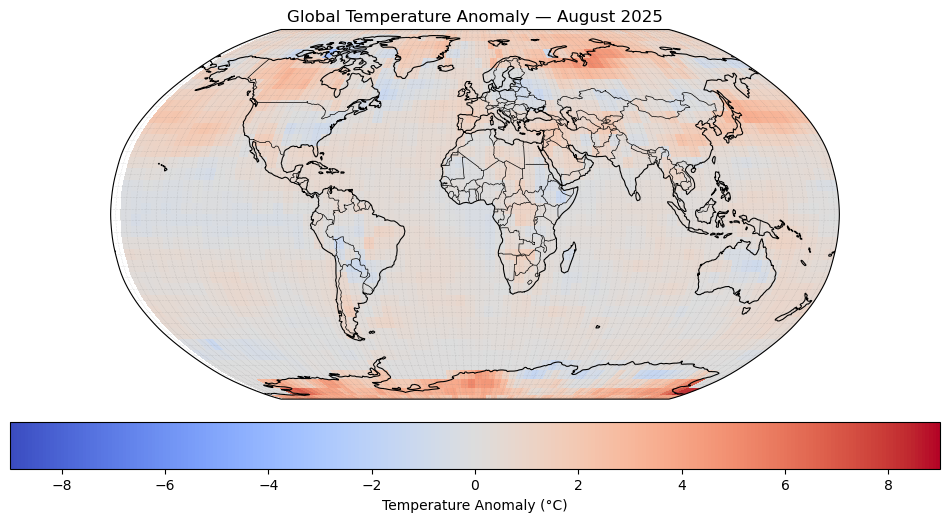

In [36]:
fig = plt.figure(figsize=(12, 6))

ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

vmax = np.ceil(np.nanmax(np.abs(grid)))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# Dense gridlines based on your data grid
gl = ax.gridlines(
    draw_labels=False,  
    linewidth=0.4,
    color="gray",
    alpha=0.4,
    linestyle=":"
)

# Set grid spacing to match your original lat/lon arrays
gl.xlocator = mticker.FixedLocator(lons_shifted)
gl.ylocator = mticker.FixedLocator(lats)

lons_shifted = np.where(lons > 180, lons - 360, lons)
lon_grid, lat_grid = np.meshgrid(lons_shifted, lats)

cmap = "YlGnBu" if mode == "pcp" else "coolwarm"

c = ax.pcolormesh(
    lon_grid,
    lat_grid,
    grid,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    shading="auto"
)

antype = "Temperature" if mode == "tavg" else "Precipitation"
dat = pd.to_datetime(month, format="%Y%m")

plt.colorbar(
    c,
    orientation="horizontal",
    pad=0.05,
    label=f"{antype} Anomaly (°C)"
)

plt.title(f"Global {antype} Anomaly — {dat.strftime('%B %Y')}")

plt.show()